In [2]:
import sys, os

# Walk up from CWD to find project root (contains config/db_config.py)
_candidate = os.path.abspath(os.getcwd())
for _ in range(4):
    if os.path.isfile(os.path.join(_candidate, 'config', 'db_config.py')):
        _root = _candidate
        break
    _candidate = os.path.dirname(_candidate)
else:
    raise RuntimeError('Could not find project root')
if _root not in sys.path:
    sys.path.insert(0, _root)

import pandas as pd
import mysql.connector
import seaborn as sns
import matplotlib.pyplot as plt
from config.db_config import DB_CONFIG
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
import numpy as np



In [3]:
# connect to MySQL DB
conn = mysql.connector.connect(**DB_CONFIG, database="salary_prediction")
cursor = conn.cursor()

# Retriving data of developers table
df_developers = pd.read_sql("SELECT * FROM developers", conn)

# Retriving data of languages table by joining
languages_sql = """
SELECT d.respondent_id, d.converted_comp_yearly, l.language_name
FROM developers d 
    INNER JOIN developer_languages dl ON d.respondent_id = dl.respondent_id 
    INNER JOIN languages l ON l.language_id = dl.language_id
ORDER BY d.respondent_id;
"""
df_language = pd.read_sql(languages_sql, conn)

# Pivot languages into binary columns (1 = used, 0 = not used) per developer
lang_pivot = df_language.pivot_table(index="respondent_id", columns="language_name", aggfunc="size", fill_value=0)
combined_df = pd.merge(df_developers, lang_pivot, on="respondent_id", how="inner")

formatted_df = pd.get_dummies(combined_df, columns=["country", "dev_type", "employment"])


In [4]:
# prepare train and test dataset
y = formatted_df["converted_comp_yearly"].copy()
X = formatted_df.drop(["respondent_id", "converted_comp_yearly"], axis=1).copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

results = []


# Baseline Models:

## Linear Regression

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error


model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = root_mean_squared_error(y_test, y_pred)

print(f"R^2: {model.score(X_test, y_test)}")
print(f"RMSE: {rmse}")

results.append({
    "model_type": "Linear Regression (Baseline)",
    "r2": model.score(X_test, y_test),
    "rmse": rmse
})

R^2: 0.597162100043481
RMSE: 32167.496344378516


## Random Forest

In [6]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_rmse = root_mean_squared_error(y_test, rf_pred)

print(f"R^2: {rf_model.score(X_test, y_test)}")
print(f"RMSE: {rf_rmse}")

results.append({
    "model_type": "Random Forest (Baseline)",
    "r2": rf_model.score(X_test, y_test),
    "rmse": rf_rmse
})

R^2: 0.6045801606062511
RMSE: 31869.9459057988


Based on the result and EDA, I decided:

- Removed `Employed_part_time`: lower salaries likely reflect fewer working hours, not the features being modeled
- Filtered `country` to top 25 (covering 80% of data) to reduce noise from underrepresented countries
- Filtered `dev_type` to top 15 (covering 91% of data) for the same reason
- Applied log transformation to salary to address right-skewed distribution
- Testing models with and without `ed_level` since correlation with salary was only 0.094
- Applied log transformation to `years_code_pro` to address right-skewed distribution (used `log1p` to handle values less than 1)

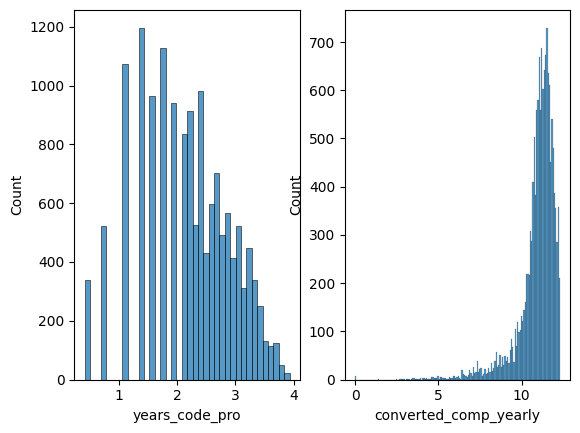

count    14939.000000
mean        10.927563
std          1.172946
min          0.000000
25%         10.667163
50%         11.192872
75%         11.608236
max         12.305918
Name: converted_comp_yearly, dtype: float64

In [7]:
# Remove Employed part time
experiment_df = combined_df[combined_df["employment"] != "Employed_part_time"]
experiment_df.head()

# Fileter top 25 countries
df_top25_countries = experiment_df["country"].value_counts().head(25)

top25 = df_top25_countries.index
experiment_df = experiment_df[experiment_df["country"].isin(top25)]

# Filter top 15 dev types
df_top_15_dev_type = experiment_df["dev_type"].value_counts().head(15)

top15_dev_type = df_top_15_dev_type.index
experiment_df = experiment_df[experiment_df["dev_type"].isin(top15_dev_type)]


# Apply log transformation on converted_comp_yearly
experiment_df["converted_comp_yearly"] = np.log(experiment_df["converted_comp_yearly"])

# Apply log transformation(log1p) on years_code_pro
experiment_df["years_code_pro"] = np.log1p(experiment_df["years_code_pro"])

fig, ax = plt.subplots(nrows=1, ncols=2)

sns.histplot(experiment_df["years_code_pro"], ax=ax[0])
sns.histplot(experiment_df["converted_comp_yearly"], ax=ax[1])
plt.show()
experiment_df["converted_comp_yearly"].describe()

It seems converted_comp_yearly contains 0, which means log(1) = 0. The original data contains the people who earn 1 dollar, so I decided to remove them.

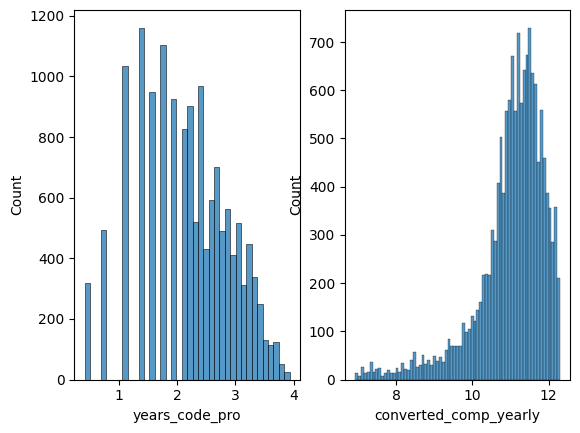

count    14702.000000
mean        11.017295
std          0.924560
min          6.914731
25%         10.683179
50%         11.206033
75%         11.623590
max         12.305918
Name: converted_comp_yearly, dtype: float64

In [8]:
# Revert log transformation
experiment_df["converted_comp_yearly"] = np.exp(experiment_df["converted_comp_yearly"])

# Remove extremely low salaries (under $1000)
experiment_df = experiment_df[experiment_df["converted_comp_yearly"] > 1000]

# Re-apply log transformation
experiment_df["converted_comp_yearly"] = np.log(experiment_df["converted_comp_yearly"])

# Verify
fig, ax = plt.subplots(nrows=1, ncols=2)
sns.histplot(experiment_df["years_code_pro"], ax=ax[0])
sns.histplot(experiment_df["converted_comp_yearly"], ax=ax[1])
plt.show()
experiment_df["converted_comp_yearly"].describe()

In [9]:
# one-hot encoding
experiment_df = pd.get_dummies(experiment_df, columns=["country", "dev_type", "employment"])
experiment_df.head()

print(f"Due to filtering top 25 countries and top 15 dev_type, the number of columns is reduced from {len(formatted_df.columns)} to {len(experiment_df.columns)}")
y = experiment_df["converted_comp_yearly"].copy()
X = experiment_df.drop(["respondent_id", "converted_comp_yearly"], axis=1).copy()


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Due to filtering top 25 countries and top 15 dev_type, the number of columns is reduced from 253 to 95


# Yes Log, Yes Filter models: 

## Liearn Regression 

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = root_mean_squared_error(y_test, y_pred)

print(f"R^2: {model.score(X_test, y_test)}")
print(f"RMSE: {rmse}")

R^2: 0.552079724425053
RMSE: 0.6327154842098757


## Random Forest 2nd

In [11]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_rmse = root_mean_squared_error(y_test, rf_pred)

print(f"R^2: {rf_model.score(X_test, y_test)}")
print(f"RMSE: {rf_rmse}")

R^2: 0.5254791201569736
RMSE: 0.6512320494255206


### Baseline vs Log + Filter

| Model | Condition | R² | RMSE |
|-------|-----------|-----|------|
| Linear Regression | Baseline | 0.597 | 32167.50 |
| Linear Regression | Log + Filter | 0.552 | 0.633 |
| Random Forest | Baseline | 0.605 | 31869.95 |
| Random Forest | Log + Filter | 0.525 | 0.651 |

Both models performed worse with log transformation and filtering applied.


# Ablation Study

To identify which preprocessing step improved performance, I tested each factor separately.


Log transformation decreased performance in all cases. Filtering alone improved both models. Proceeding with filtering only.

## Log Only
### Linear Regression

In [12]:
log_df = combined_df.copy()
log_df["converted_comp_yearly"] = np.log(log_df["converted_comp_yearly"])
log_df["years_code_pro"] = np.log1p(log_df["years_code_pro"])

log_formatted = pd.get_dummies(log_df, columns=["country", "dev_type", "employment"])

y_log = log_formatted["converted_comp_yearly"].copy()
X_log = log_formatted.drop(["respondent_id", "converted_comp_yearly"], axis=1).copy()
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X_log, y_log, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train_log, y_train_log)
y_pred = model.predict(X_test_log)
rmse = root_mean_squared_error(y_test_log, y_pred)
print(f"R^2: {model.score(X_test_log, y_test_log)}")
print(f"RMSE: {rmse}")

R^2: 0.4224710564569135
RMSE: 1.0459274220339816


### Random Forest

In [13]:
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train_log, y_train_log)
rf_pred = rf_model.predict(X_test_log)
rf_rmse = root_mean_squared_error(y_test_log, rf_pred)
print(f"R^2: {rf_model.score(X_test_log, y_test_log)}")
print(f"RMSE: {rf_rmse}")

R^2: 0.3442077800103619
RMSE: 1.1145454990001382


## Filter Only
### Linear Regression

In [14]:
filter_df = combined_df[combined_df["employment"] != "Employed_part_time"]
top25 = filter_df["country"].value_counts().head(25).index
filter_df = filter_df[filter_df["country"].isin(top25)]
top15_dev = filter_df["dev_type"].value_counts().head(15).index
filter_df = filter_df[filter_df["dev_type"].isin(top15_dev)]

filter_formatted = pd.get_dummies(filter_df, columns=["country", "dev_type", "employment"])

y_f = filter_formatted["converted_comp_yearly"].copy()
X_f = filter_formatted.drop(["respondent_id", "converted_comp_yearly"], axis=1).copy()
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_f, y_f, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train_f, y_train_f)
y_pred = model.predict(X_test_f)
rmse = root_mean_squared_error(y_test_f, y_pred)
print(f"R^2: {model.score(X_test_f, y_test_f)}")
print(f"RMSE: {rmse}")

results.append({
    "model_type": "Linear Regression (Filtered)",
    "r2": model.score(X_test_f, y_test_f),
    "rmse": rmse
})

R^2: 0.6200339213354646
RMSE: 32018.998627549063


### Random Forest

In [15]:
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train_f, y_train_f)
rf_pred = rf_model.predict(X_test_f)
rf_rmse = root_mean_squared_error(y_test_f, rf_pred)
print(f"R^2: {rf_model.score(X_test_f, y_test_f)}")
print(f"RMSE: {rf_rmse}")

results.append({
    "model_type": "Random Forest (Filtered)",
    "r2": rf_model.score(X_test_f, y_test_f),
    "rmse": rf_rmse
})


R^2: 0.6378192800010789
RMSE: 31260.649420621477


## Ablation Study Result

### Linear Regression

| Condition | R² | RMSE |
|-----------|-----|------|
| Baseline | 0.597 | 32167.50 |
| Log + Filter | 0.552 | 0.633 |
| Log Only | 0.422 | 1.046 |
| Filter Only | 0.620 | 32019.00 |

### Random Forest

| Condition | R² | RMSE |
|-----------|-----|------|
| Baseline | 0.605 | 31869.95 |
| Log + Filter | 0.525 | 0.651 |
| Log Only | 0.344 | 1.115 |
| Filter Only | 0.638 | 31260.65 |

Filtering improved performance while log transformation consistently decreased it. Proceeding with Filter Only for the remaining models.

# Further Exploration

Filter Only showed the best results, so I tested additional models to see if performance could be further improved.

Gradient Boosting and XGBoost are ensemble methods that build trees sequentially, correcting previous errors. They often outperform Random Forest on structured data.

## Gradient Boosting

In [16]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train_f, y_train_f)

gb_pred = gb_model.predict(X_test_f)
gb_rmse = root_mean_squared_error(y_test_f, gb_pred)

print(f"R^2: {gb_model.score(X_test_f, y_test_f)}")
print(f"RMSE: {gb_rmse}")

results.append({
    "model_type": "Gradient Boosting (Filtered)",
    "r2": gb_model.score(X_test_f, y_test_f),
    "rmse": gb_rmse
})

R^2: 0.6350861059462704
RMSE: 31378.380988300596


## XGBoost

In [17]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(random_state=42)
xgb_model.fit(X_train_f, y_train_f)

xgb_pred = xgb_model.predict(X_test_f)
xgb_rmse = root_mean_squared_error(y_test_f, xgb_pred)

print(f"R^2: {xgb_model.score(X_test_f, y_test_f)}")
print(f"RMSE: {xgb_rmse}")

results.append({
    "model_type": "XGBoost (Filtered)",
    "r2": xgb_model.score(X_test_f, y_test_f),
    "rmse": xgb_rmse
})

R^2: 0.6498772762552684
RMSE: 30735.86792232954


### Result

| Model | R² | RMSE |
|-------|-----|------|
| Gradient Boosting | 0.635 | 31378.38 |
| XGBoost | 0.650 | 30735.87 |

XGBoost achieved the highest R² so far. Proceeding with hyperparameter tuning using GridSearchCV to optimize XGBoost further.

In [18]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [300, 500, 1000],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8]
}

grid_search = GridSearchCV(XGBRegressor(random_state=42), param_grid, cv=3, scoring='r2', n_jobs=-1)
grid_search.fit(X_train_f, y_train_f)

print(f"Best params: {grid_search.best_params_}")
print(f"Best R^2: {grid_search.best_score_}")

best_model = grid_search.best_estimator_
best_pred = best_model.predict(X_test_f)
best_rmse = root_mean_squared_error(y_test_f, best_pred)

print(f"R^2: {best_model.score(X_test_f, y_test_f)}")
print(f"RMSE: {best_rmse}")

results.append({
    "model_type": "XGBoost + GridSearchCV (Filtered)",
    "r2": best_model.score(X_test_f, y_test_f),
    "rmse": best_rmse
})

Best params: {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 1000, 'subsample': 0.7}
Best R^2: 0.6594822302979495
R^2: 0.6704406812204857
RMSE: 29819.621752404484


## Conclusion

| Model | R² | RMSE |
|-------|-----|------|
| Linear Regression (Baseline) | 0.597 | 32167.50 |
| Random Forest (Baseline) | 0.605 | 31869.95 |
| Linear Regression (Filtered) | 0.620 | 32019.00 |
| Random Forest (Filtered) | 0.638 | 31260.65 |
| Gradient Boosting (Filtered) | 0.635 | 31378.38 |
| XGBoost (Filtered) | 0.650 | 30735.87 |
| XGBoost + GridSearchCV (Filtered) | 0.670 | 29819.62 |

XGBoost with hyperparameter tuning achieved the best performance, improving R² from 0.597 (baseline) to 0.670. Log transformation was tested but decreased performance, while filtering underrepresented categories improved all models.

The R² of 0.67 indicates that the model explains about 67% of salary variance. The remaining 33% is likely influenced by factors not captured in this dataset, such as company size, industry, and cost of living.

In [19]:
# Get respondent IDs for test data
test_ids = filter_formatted.loc[X_test_f.index, "respondent_id"].values

# Collect predictions from all models
predictions = []
for name, preds in [("LinearRegression", model.predict(X_test_f)),
                     ("RandomForest", rf_model.predict(X_test_f)),
                     ("GradientBoosting", gb_model.predict(X_test_f)),
                     ("XGBoost_tuned", best_model.predict(X_test_f))]:
    for rid, pred in zip(test_ids, preds):
        predictions.append((int(rid), float(pred), name))

# Save to predictions table
conn = mysql.connector.connect(**DB_CONFIG, database="salary_prediction")
cursor = conn.cursor()

insert_sql = """
    INSERT INTO predictions (respondent_id, predicted_salary, model_type)
    VALUES (%s, %s, %s)
"""

try:
    cursor.executemany(insert_sql, predictions)
    conn.commit()
    print(f"predictions: {len(predictions)} rows inserted")
except Exception as e:
    conn.rollback()
    print(f"Error: {e}")
finally:
    cursor.close()
    conn.close()

predictions: 11952 rows inserted


In [20]:
# add RMSE and R^2 to model_results table
# connect to MySQL DB
conn = mysql.connector.connect(**DB_CONFIG, database="salary_prediction")
cursor = conn.cursor()

try:
    cursor.executemany(
        "INSERT INTO model_results (model_type, r2, rmse) VALUES (%(model_type)s, %(r2)s, %(rmse)s)",
        results
    )    
    conn.commit()
    print(f"model_results: {len(results)} rows inserted")
except Exception as e:
    conn.rollback()
    print(f"Error: {e}")
finally:
    cursor.close()
    conn.close()





model_results: 7 rows inserted
